In [27]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import hdf5plugin
import config

from autoencoder import process_thumbnails

In [66]:
groups=['ps20nm', 'ps30nm', 'ps40nm', 'ps50nm']


data = {}
for group in groups:
    data[group] = {}

data['ps20nm']['xlim'] = [300,500]
data['ps20nm']['ylim'] = [0,200]

data['ps30nm']['xlim'] = [300,450]
data['ps30nm']['ylim'] = [50,175]

data['ps40nm']['xlim'] = [300,500]
data['ps40nm']['ylim'] = [25,175]

data['ps50nm']['xlim'] = [300,450]
data['ps50nm']['ylim'] = [25,175]

data['ps20nm']['pixmin'] = 20
data['ps20nm']['pixmax'] = 30
data['ps30nm']['pixmin'] = 20
data['ps30nm']['pixmax'] = 30
data['ps40nm']['pixmin'] = 20
data['ps40nm']['pixmax'] = 30
data['ps50nm']['pixmin'] = 20
data['ps50nm']['pixmax'] = 30

with h5py.File(f'{config.DATA_DIR}/thumbnails.h5', 'r') as f:
    for group in groups:
        
        data[group]['is'] = f[f'/{group}/is'][:]
        data[group]['xs'] = f[f'/{group}/xs'][:]
        data[group]['ys'] = f[f'/{group}/ys'][:]
        data[group]['flags'] = f[f'/{group}/flags'][:] #fliter focus condtion
        data[group]['thumbs'] = f[f'/{group}/thumbnails'][:]
        
        #data[group]['nm'] = int(group[2:4])
        #data[group]['is_mean'] = np.mean(data[group]['is'][data[group]['flags']])
        #data[group]['is_median'] = np.median(data[group]['is'][data[group]['flags']])
        



In [67]:
proc.sum(axis=(1,2))

array([ 76.,   0.,  59., ..., 253.,  70.,  42.],
      shape=(5392,), dtype=float32)

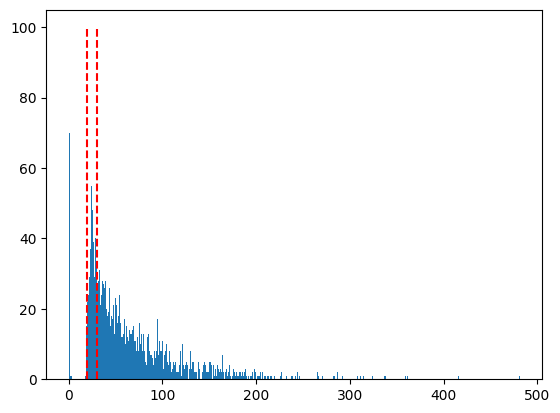

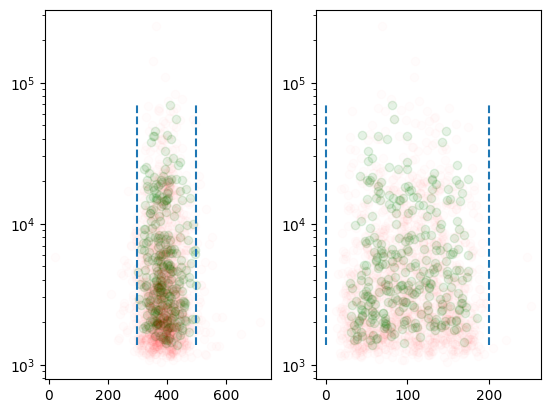

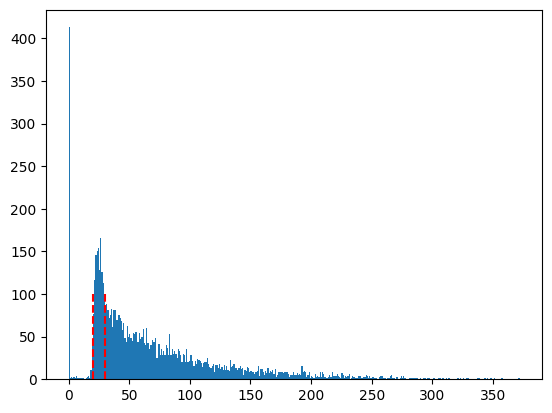

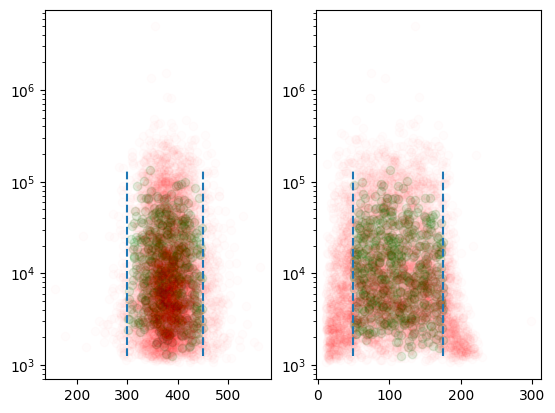

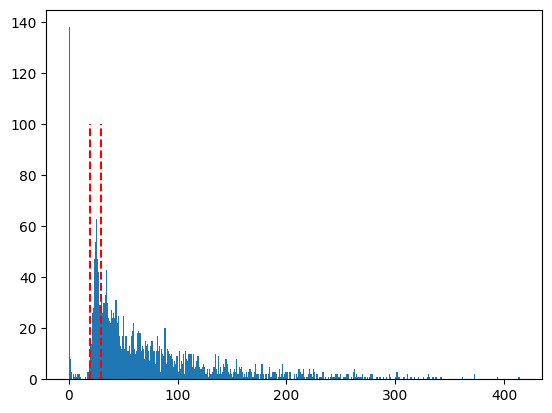

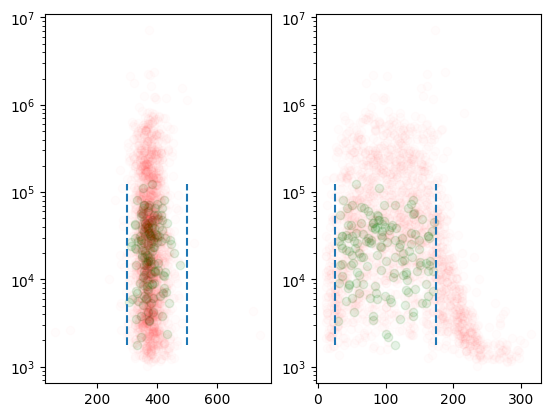

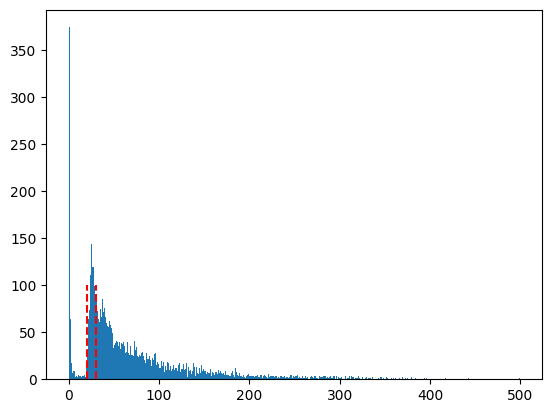

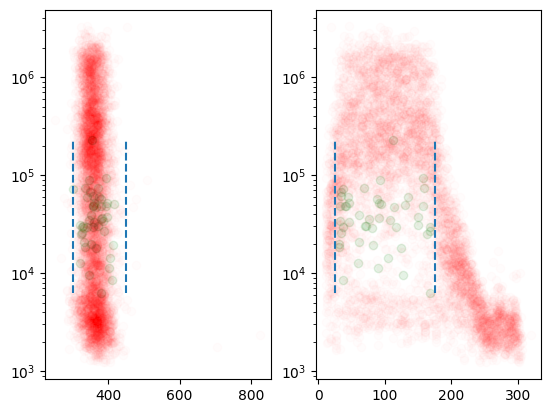

In [68]:

for group in groups:
    proc = process_thumbnails(data[group]['thumbs'], thresh=0.1).squeeze()
    data['ps20nm']['proc'] = proc

    plt.figure()
    plt.hist(proc.sum(axis=(1,2)),bins=int(proc.sum(axis=(1,2)).max()))
    plt.vlines([data[group]['pixmin'],data[group]['pixmax']], color='red', linestyle='dashed', ymin=0, ymax=100)
    fig, ax = plt.subplots(1,2)
    data[group]['flags'] = (data[group]['xs']>data[group]['xlim'][0]) & (data[group]['xs']<data[group]['xlim'][1])& (data[group]['flags'])
    data[group]['flags'] = (data[group]['ys']>data[group]['ylim'][0]) & (data[group]['ys']<data[group]['ylim'][1])& (data[group]['flags'])
    
    data[group]['flags'] = (proc.sum(axis=(1,2))>data[group]['pixmin']) & (proc.sum(axis=(1,2))<data[group]['pixmax']) & (data[group]['flags'])
    
    ax[0].scatter(data[group]['xs'][data[group]['flags']], data[group]['is'][data[group]['flags']], color='g',alpha=0.1)
    ax[0].scatter(data[group]['xs'][~data[group]['flags']], data[group]['is'][~data[group]['flags']], color='r',alpha=0.01)
    ax[0].vlines(x=data[group]['xlim'], ymin=data[group]['is'][data[group]['flags']].min(),  ymax=data[group]['is'][data[group]['flags']].max(), linestyle='dashed')
 
    ax[1].scatter(data[group]['ys'][data[group]['flags']], data[group]['is'][data[group]['flags']], color='g',alpha=0.1)
    ax[1].scatter(data[group]['ys'][~data[group]['flags']], data[group]['is'][~data[group]['flags']], color='r',alpha=0.01)
    ax[1].vlines(x=data[group]['ylim'], ymin=data[group]['is'][data[group]['flags']].min(),  ymax=data[group]['is'][data[group]['flags']].max(), linestyle='dashed')
 
    ax[0].set_yscale('log')
    ax[1].set_yscale('log')
    #plt.scatter(data[group]['nm'], data[group]['median']**(6))

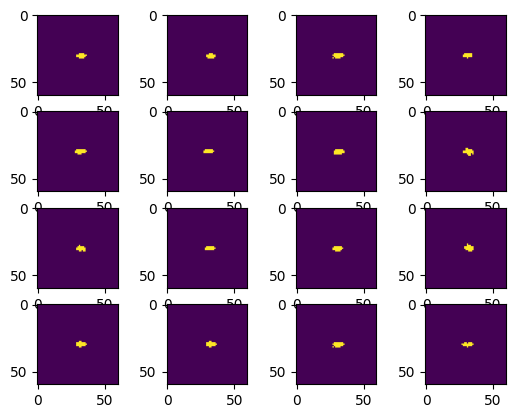

In [69]:
fig, axs = plt.subplots(4,4)
for ax in axs.flatten():
    flat_index = np.random.choice(np.flatnonzero(data[group]['flags']))
    ax.imshow(proc[flat_index,:,:])


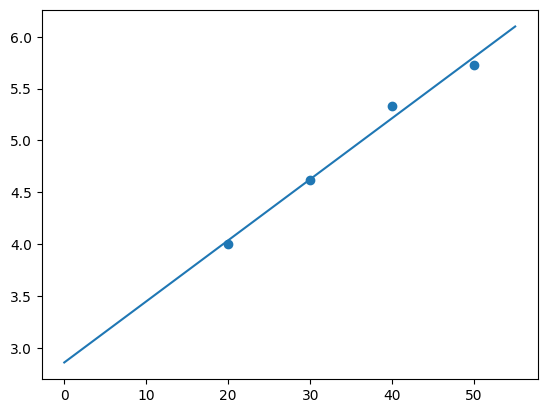

In [70]:
nm = [20,30,40, 50]
i_median = []
for group in groups:
    i_median.append(np.median(data[group]['is'][data[group]['flags']]))
i_median = np.array(i_median)**(1/6)

m, c  = np.polyfit(nm, i_median, 1)
    
plt.figure()
plt.scatter(nm, i_median)

x_fit = np.linspace(0, 55)
y_fit = m*x_fit + c
plt.plot(x_fit, y_fit)




In [71]:
print(i_median)

[4.00371277 4.61701553 5.33165298 5.73088965]


In [ ]:
[4.02141664 4.57443194 5.18928872 5.66268377]